# Ames Housing Price Prediction

## Load Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
import warnings
import pickle

warnings.filterwarnings('ignore')
sns.set_theme(style="darkgrid")

## Load Data

In [2]:
df_train = pd.read_csv("data/train.csv")
df_test  = pd.read_csv("data/test.csv")

df_train.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Feature Engineering

In [3]:
# Fill missings that feed into derived features
df_train['BsmtFinSF1']   = df_train['BsmtFinSF1'].fillna(0)
df_train['BsmtFinSF2']   = df_train['BsmtFinSF2'].fillna(0)
df_train['BsmtFullBath'] = df_train['BsmtFullBath'].fillna(0)
df_train['BsmtHalfBath'] = df_train['BsmtHalfBath'].fillna(0)
df_train['GarageYrBlt']  = df_train['GarageYrBlt'].fillna(df_train['YearBuilt'])

# Derived features
df_train['TotalFloorSF']     = df_train['1stFlrSF'] + df_train['2ndFlrSF']
df_train['TotalSqftCalc']    = df_train['BsmtFinSF1'] + df_train['BsmtFinSF2'] + df_train['GrLivArea']
df_train['HouseAge']         = df_train['YrSold'] - df_train['YearBuilt']
df_train['RemodAge']         = df_train['YrSold'] - df_train['YearRemodAdd']
df_train['TotalBath']        = df_train['FullBath'] + df_train['HalfBath'] * 0.5 + df_train['BsmtFullBath'] + df_train['BsmtHalfBath'] * 0.5
df_train['QualityIndex']     = df_train['OverallQual'] * df_train['OverallCond']
df_train['GarageAge']        = df_train['YrSold'] - df_train['GarageYrBlt']
df_train['TotalPorchSF']     = df_train['OpenPorchSF'] + df_train['EnclosedPorch'] + df_train['ScreenPorch']
df_train['TotalOutdoorSF']   = df_train['WoodDeckSF'] + df_train['OpenPorchSF'] + df_train['EnclosedPorch'] + df_train['ScreenPorch']
df_train['logSalePrice']     = np.log(df_train['SalePrice'])
df_train['logTotalSqftCalc'] = np.log(df_train['TotalSqftCalc'])

df_train[['SalePrice', 'logSalePrice', 'TotalFloorSF', 'HouseAge', 'RemodAge', 'TotalBath', 'QualityIndex']].describe()

,SalePrice,logSalePrice,TotalFloorSF,HouseAge,RemodAge,TotalBath,QualityIndex
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,180921.195890,12.024051,1509.619178,36.547945,22.950000,2.210616,33.864384
std,79442.502883,0.399452,521.163523,30.250152,20.640653,0.785399,9.219624
min,34900.000000,10.460242,334.000000,0.000000,-1.000000,1.000000,1.000000
25%,129975.000000,11.775097,1123.750000,8.000000,4.000000,2.000000,30.000000
50%,163000.000000,12.001505,1458.000000,35.000000,14.000000,2.000000,35.000000
75%,214000.000000,12.273731,1775.250000,54.000000,41.000000,2.500000,40.000000
max,755000.000000,13.534473,5642.000000,136.000000,60.000000,6.000000,90.000000


In [4]:
# Remove large-lot outliers flagged in the Ames documentation
sample_df = df_train[df_train['GrLivArea'] <= 4000].copy()
print(f"Rows removed: {len(df_train) - len(sample_df)}")
print(f"Final sample: {len(sample_df)}")

Rows removed: 4
Final sample: 1456


In [5]:
# Neighborhood bins based on median sale price (derived from training data only)
nbhd_summary = (sample_df.groupby('Neighborhood')['SalePrice']
                .median()
                .reset_index()
                .rename(columns={'SalePrice': 'MedianSalePrice'}))

nbhd_summary['NbhdBin'] = pd.qcut(nbhd_summary['MedianSalePrice'],
                                   q=4, labels=['grp1', 'grp2', 'grp3', 'grp4'])

nbhd_mapping = nbhd_summary.set_index('Neighborhood')['NbhdBin'].to_dict()

sample_df = sample_df.merge(nbhd_summary[['Neighborhood', 'NbhdBin']],
                            on='Neighborhood', how='left')

sample_df['NbhdBin'] = pd.Categorical(sample_df['NbhdBin'],
                                      categories=['grp1', 'grp2', 'grp3', 'grp4'],
                                      ordered=True)

print(sample_df['NbhdBin'].value_counts().sort_index())

NbhdBin
grp1    413
grp2    369
grp3    398
grp4    276
Name: count, dtype: int64


In [6]:
# NbhdBin (reference = grp1)
sample_df['d_NbhdBin_grp2'] = (sample_df['NbhdBin'] == 'grp2').astype(int)
sample_df['d_NbhdBin_grp3'] = (sample_df['NbhdBin'] == 'grp3').astype(int)
sample_df['d_NbhdBin_grp4'] = (sample_df['NbhdBin'] == 'grp4').astype(int)

# BldgType (reference = 1Fam)
sample_df['d_BldgType_2fmCon'] = (sample_df['BldgType'] == '2fmCon').astype(int)
sample_df['d_BldgType_Duplex'] = (sample_df['BldgType'] == 'Duplex').astype(int)
sample_df['d_BldgType_Twnhs']  = (sample_df['BldgType'] == 'Twnhs').astype(int)
sample_df['d_BldgType_TwnhsE'] = (sample_df['BldgType'] == 'TwnhsE').astype(int)

# SaleCondition (reference = Normal)
sample_df['d_SaleCond_Abnorml'] = (sample_df['SaleCondition'] == 'Abnorml').astype(int)
sample_df['d_SaleCond_AdjLand'] = (sample_df['SaleCondition'] == 'AdjLand').astype(int)
sample_df['d_SaleCond_Alloca']  = (sample_df['SaleCondition'] == 'Alloca').astype(int)
sample_df['d_SaleCond_Family']  = (sample_df['SaleCondition'] == 'Family').astype(int)
sample_df['d_SaleCond_Partial'] = (sample_df['SaleCondition'] == 'Partial').astype(int)

# HouseStyle (reference = 1Story)
sample_df['d_HStyle_2Story'] = (sample_df['HouseStyle'] == '2Story').astype(int)
sample_df['d_HStyle_1_5Fin'] = (sample_df['HouseStyle'] == '1.5Fin').astype(int)
sample_df['d_HStyle_SLvl']   = (sample_df['HouseStyle'] == 'SLvl').astype(int)
sample_df['d_HStyle_SFoyer'] = (sample_df['HouseStyle'] == 'SFoyer').astype(int)
sample_df['d_HStyle_1_5Unf'] = (sample_df['HouseStyle'] == '1.5Unf').astype(int)
sample_df['d_HStyle_2_5Unf'] = (sample_df['HouseStyle'] == '2.5Unf').astype(int)
sample_df['d_HStyle_2_5Fin'] = (sample_df['HouseStyle'] == '2.5Fin').astype(int)

# ExterQual (reference = TA)
sample_df['d_ExterQual_Gd'] = (sample_df['ExterQual'] == 'Gd').astype(int)
sample_df['d_ExterQual_Ex'] = (sample_df['ExterQual'] == 'Ex').astype(int)
sample_df['d_ExterQual_Fa'] = (sample_df['ExterQual'] == 'Fa').astype(int)

# ExterCond (reference = TA)
sample_df['d_ExterCond_Gd'] = (sample_df['ExterCond'] == 'Gd').astype(int)
sample_df['d_ExterCond_Fa'] = (sample_df['ExterCond'] == 'Fa').astype(int)
sample_df['d_ExterCond_Ex'] = (sample_df['ExterCond'] == 'Ex').astype(int)
sample_df['d_ExterCond_Po'] = (sample_df['ExterCond'] == 'Po').astype(int)

# KitchenQual (reference = TA)
sample_df['d_KitchQual_Gd'] = (sample_df['KitchenQual'] == 'Gd').astype(int)
sample_df['d_KitchQual_Ex'] = (sample_df['KitchenQual'] == 'Ex').astype(int)
sample_df['d_KitchQual_Fa'] = (sample_df['KitchenQual'] == 'Fa').astype(int)
sample_df['d_KitchQual_Po'] = (sample_df['KitchenQual'] == 'Po').astype(int)

dummy_cols = [col for col in sample_df.columns if col.startswith('d_')]
print(dummy_cols)

['d_NbhdBin_grp2', 'd_NbhdBin_grp3', 'd_NbhdBin_grp4', 'd_BldgType_2fmCon', 'd_BldgType_Duplex', 'd_BldgType_Twnhs', 'd_BldgType_TwnhsE', 'd_SaleCond_Abnorml', 'd_SaleCond_AdjLand', 'd_SaleCond_Alloca', 'd_SaleCond_Family', 'd_SaleCond_Partial', 'd_HStyle_2Story', 'd_HStyle_1_5Fin', 'd_HStyle_SLvl', 'd_HStyle_SFoyer', 'd_HStyle_1_5Unf', 'd_HStyle_2_5Unf', 'd_HStyle_2_5Fin', 'd_ExterQual_Gd', 'd_ExterQual_Ex', 'd_ExterQual_Fa', 'd_ExterCond_Gd', 'd_ExterCond_Fa', 'd_ExterCond_Ex', 'd_ExterCond_Po', 'd_KitchQual_Gd', 'd_KitchQual_Ex', 'd_KitchQual_Fa', 'd_KitchQual_Po']


In [7]:
# Missing value check
missing_df = pd.DataFrame({
    'Missing_Count':   sample_df.isnull().sum(),
    'Missing_Percent': (sample_df.isnull().sum() / len(sample_df)) * 100
}).sort_values(by='Missing_Count', ascending=False)

missing_df = missing_df[missing_df['Missing_Count'] > 0]
print(missing_df)

              Missing_Count  Missing_Percent
PoolQC                 1451        99.656593
MiscFeature            1402        96.291209
Alley                  1365        93.750000
Fence                  1176        80.769231
MasVnrType              871        59.821429
FireplaceQu             690        47.390110
LotFrontage             259        17.788462
GarageFinish             81         5.563187
GarageType               81         5.563187
GarageQual               81         5.563187
GarageCond               81         5.563187
BsmtFinType2             38         2.609890
BsmtExposure             38         2.609890
BsmtQual                 37         2.541209
BsmtCond                 37         2.541209
BsmtFinType1             37         2.541209
MasVnrArea                8         0.549451
Electrical                1         0.068681


## EDA

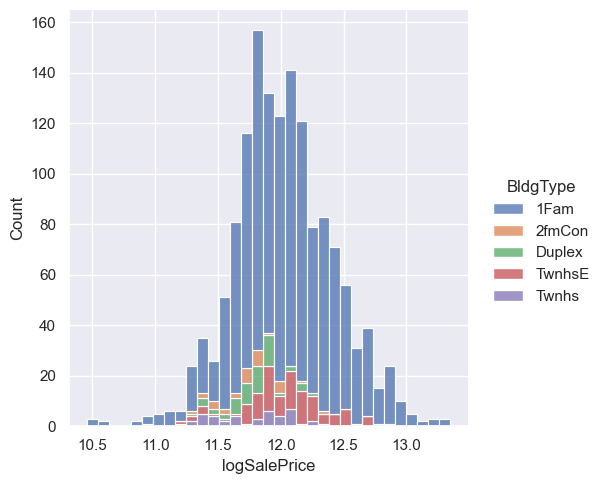

In [8]:
sns.displot(data=sample_df, x="logSalePrice", hue="BldgType", multiple="stack")

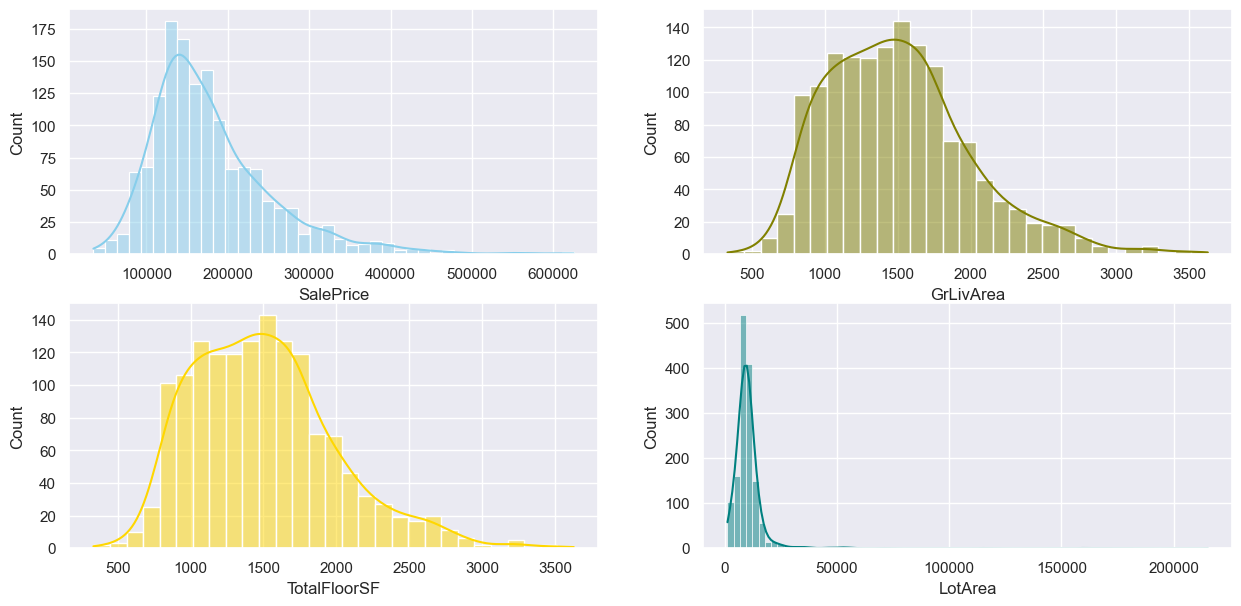

In [9]:
fig, axs = plt.subplots(2, 2, figsize=(15, 7))

sns.histplot(data=sample_df, x="SalePrice",    kde=True, color="skyblue", ax=axs[0, 0])
sns.histplot(data=sample_df, x="GrLivArea",    kde=True, color="olive",   ax=axs[0, 1])
sns.histplot(data=sample_df, x="TotalFloorSF", kde=True, color="gold",    ax=axs[1, 0])
sns.histplot(data=sample_df, x="LotArea",      kde=True, color="teal",    ax=axs[1, 1])

plt.show()

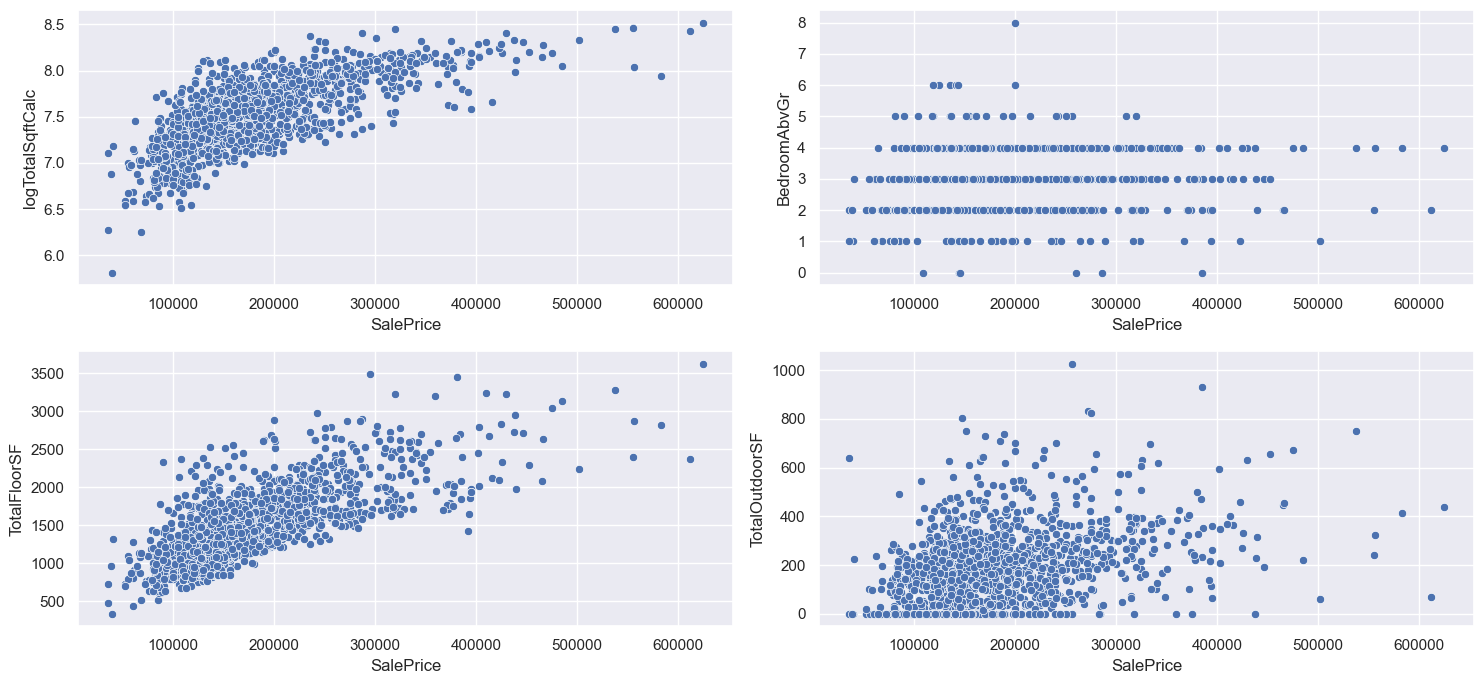

In [10]:
fig, axs = plt.subplots(2, 2, figsize=(15, 7))

sns.scatterplot(x=sample_df["SalePrice"], y=sample_df["logTotalSqftCalc"], ax=axs[0, 0])
sns.scatterplot(x=sample_df["SalePrice"], y=sample_df["BedroomAbvGr"],     ax=axs[0, 1])
sns.scatterplot(x=sample_df["SalePrice"], y=sample_df["TotalFloorSF"],     ax=axs[1, 0])
sns.scatterplot(x=sample_df["SalePrice"], y=sample_df["TotalOutdoorSF"],   ax=axs[1, 1])

plt.tight_layout()
plt.show()

<Axes: xlabel='SaleCondition', ylabel='logSalePrice'>

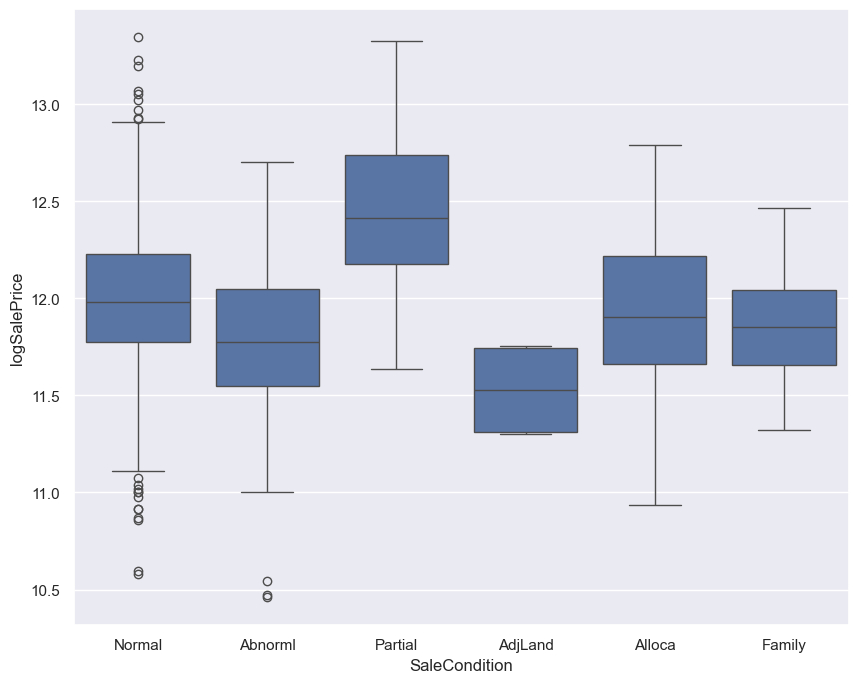

In [11]:
plt.figure(figsize=(10, 8))
sns.boxplot(x='SaleCondition', y='logSalePrice', data=sample_df)

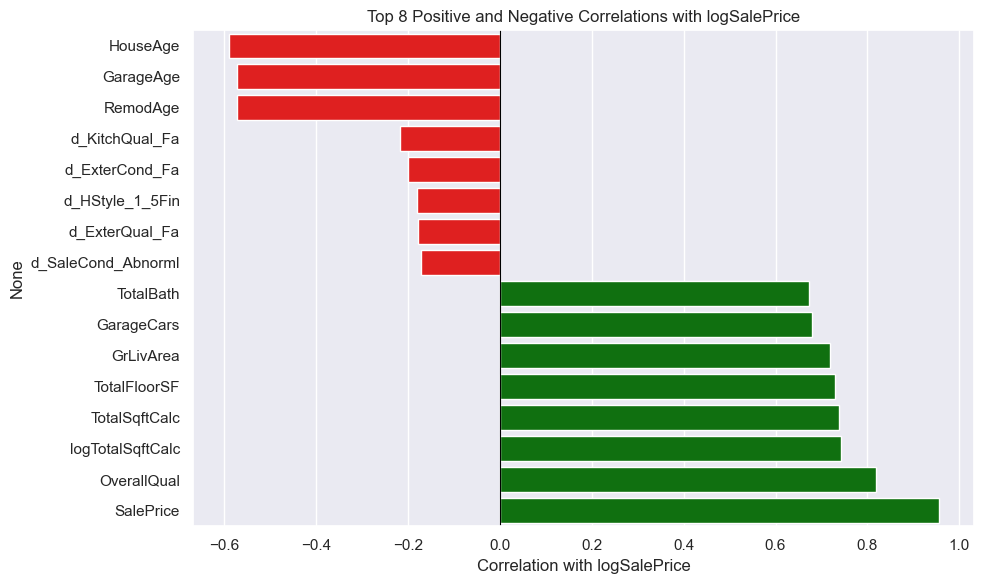

In [12]:
corr_saleprice = sample_df.select_dtypes(include=[np.number]).corr()['logSalePrice'].drop('logSalePrice')

top_pos = corr_saleprice.sort_values(ascending=False).head(8)
top_neg = corr_saleprice.sort_values(ascending=True).head(8)
top_correlations = pd.concat([top_pos, top_neg]).sort_values()

plt.figure(figsize=(10, 6))
sns.barplot(x=top_correlations.values, y=top_correlations.index,
            palette=['red' if x < 0 else 'green' for x in top_correlations.values])
plt.xlabel('Correlation with logSalePrice')
plt.title('Top 8 Positive and Negative Correlations with logSalePrice')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.tight_layout()
plt.show()

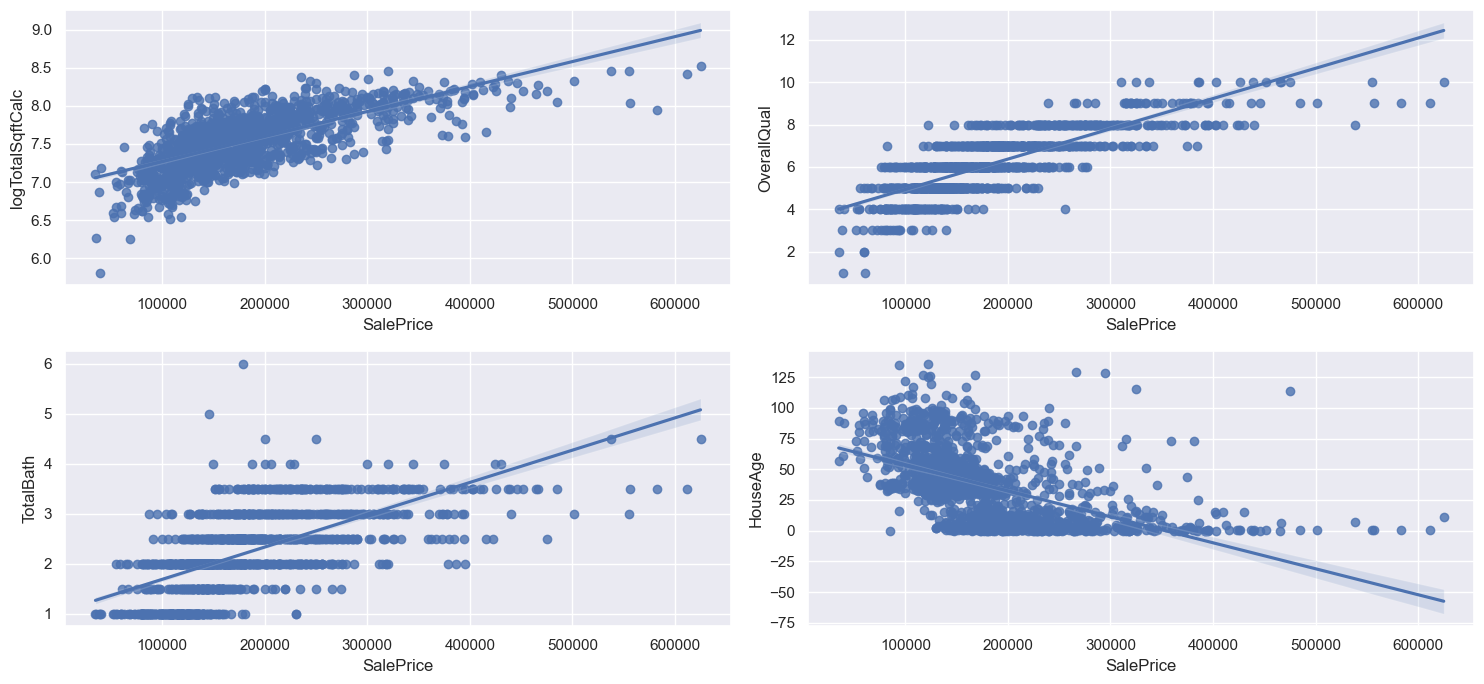

In [13]:
fig, axs = plt.subplots(2, 2, figsize=(15, 7))

sns.regplot(x="SalePrice", y="logTotalSqftCalc", data=sample_df, ax=axs[0, 0])
sns.regplot(x="SalePrice", y="OverallQual",      data=sample_df, ax=axs[0, 1])
sns.regplot(x="SalePrice", y="TotalBath",        data=sample_df, ax=axs[1, 0])
sns.regplot(x="SalePrice", y="HouseAge",         data=sample_df, ax=axs[1, 1])

plt.tight_layout()
plt.show()

## Linear Regression

In [14]:
Model1 = ols(
    '''logSalePrice ~ TotalFloorSF +
                      HouseAge +
                      TotalOutdoorSF +
                      TotalBath +
                      QualityIndex +
                      d_NbhdBin_grp2 +
                      d_NbhdBin_grp3 +
                      d_NbhdBin_grp4 +
                      d_BldgType_2fmCon +
                      d_BldgType_Duplex +
                      d_BldgType_Twnhs +
                      d_BldgType_TwnhsE +
                      d_SaleCond_Abnorml +
                      d_SaleCond_AdjLand +
                      d_SaleCond_Alloca +
                      d_SaleCond_Family +
                      d_SaleCond_Partial +
                      d_KitchQual_Gd +
                      d_KitchQual_Ex +
                      d_KitchQual_Fa +
                      d_KitchQual_Po''',
    data=sample_df
).fit()

print(Model1.summary())

                            OLS Regression Results                            
Dep. Variable:           logSalePrice   R-squared:                       0.875
Model:                            OLS   Adj. R-squared:                  0.873
Method:                 Least Squares   F-statistic:                     500.1
Date:                Sun, 07 Jun 2026   Prob (F-statistic):               0.00
Time:                        00:43:56   Log-Likelihood:                 794.07
No. Observations:                1456   AIC:                            -1546.
Df Residuals:                    1435   BIC:                            -1435.
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             11.1181      0

In [15]:
print(sm.stats.anova_lm(Model1, typ=1))

                        df      sum_sq     mean_sq            F         PR(>F)
TotalFloorSF           1.0  121.446503  121.446503  6084.980551   0.000000e+00
HouseAge               1.0   45.002163   45.002163  2254.797606  1.403159e-296
TotalOutdoorSF         1.0    3.536198    3.536198   177.178414   3.333218e-38
TotalBath              1.0    1.148351    1.148351    57.537231   5.930861e-14
QualityIndex           1.0   18.103137   18.103137   907.043289  7.688301e-155
d_NbhdBin_grp2         1.0    0.008061    0.008061     0.403875   5.251959e-01
d_NbhdBin_grp3         1.0    0.009161    0.009161     0.459006   4.981980e-01
d_NbhdBin_grp4         1.0    4.247566    4.247566   212.820941   4.722511e-45
d_BldgType_2fmCon      1.0    0.015002    0.015002     0.751652   3.860987e-01
d_BldgType_Duplex      1.0    0.405860    0.405860    20.335311   7.028198e-06
d_BldgType_Twnhs       1.0    2.015008    2.015008   100.960373   5.295898e-23
d_BldgType_TwnhsE      1.0    0.532633    0.532633  

In [16]:
Model2 = ols(
    '''logSalePrice ~ logTotalSqftCalc +
                      QualityIndex +
                      HouseAge +
                      TotalBath +
                      GarageArea +
                      BedroomAbvGr +
                      d_NbhdBin_grp2 +
                      d_NbhdBin_grp3 +
                      d_NbhdBin_grp4 +
                      d_BldgType_2fmCon +
                      d_BldgType_Duplex +
                      d_BldgType_Twnhs +
                      d_BldgType_TwnhsE +
                      d_SaleCond_Abnorml +
                      d_SaleCond_AdjLand +
                      d_SaleCond_Alloca +
                      d_SaleCond_Family +
                      d_SaleCond_Partial +
                      d_ExterQual_Gd +
                      d_ExterQual_Ex +
                      d_ExterQual_Fa +
                      d_KitchQual_Gd +
                      d_KitchQual_Ex +
                      d_KitchQual_Fa +
                      d_KitchQual_Po''',
    data=sample_df
).fit()

print(Model2.summary())

                            OLS Regression Results                            
Dep. Variable:           logSalePrice   R-squared:                       0.884
Model:                            OLS   Adj. R-squared:                  0.882
Method:                 Least Squares   F-statistic:                     456.1
Date:                Sun, 07 Jun 2026   Prob (F-statistic):               0.00
Time:                        00:44:00   Log-Likelihood:                 853.60
No. Observations:                1456   AIC:                            -1657.
Df Residuals:                    1431   BIC:                            -1525.
Df Model:                          24                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              8.3830      0

In [17]:
print(sm.stats.anova_lm(Model2, typ=1))

                        df      sum_sq     mean_sq            F         PR(>F)
logTotalSqftCalc       1.0  125.985764  125.985764  6831.218231   0.000000e+00
QualityIndex           1.0   28.643039   28.643039  1553.087009  1.253476e-230
HouseAge               1.0   30.717865   30.717865  1665.588495  3.903543e-242
TotalBath              1.0    0.123528    0.123528     6.697977   9.749972e-03
GarageArea             1.0    5.176920    5.176920   280.703687   1.140533e-57
BedroomAbvGr           1.0    0.328965    0.328965    17.837191   2.558207e-05
d_NbhdBin_grp2         1.0    0.778487    0.778487    42.211212   1.127909e-10
d_NbhdBin_grp3         1.0    0.011201    0.011201     0.607320   4.359274e-01
d_NbhdBin_grp4         1.0    4.274538    4.274538   231.774610   1.270422e-48
d_BldgType_2fmCon      1.0    0.048690    0.048690     2.640094   1.044176e-01
d_BldgType_Duplex      1.0    0.321161    0.321161    17.414035   3.187019e-05
d_BldgType_Twnhs       1.0    1.301223    1.301223  

In [18]:
cv_features = [
    'logTotalSqftCalc', 'QualityIndex', 'HouseAge', 'TotalBath',
    'GarageArea', 'BedroomAbvGr',
    'd_NbhdBin_grp2', 'd_NbhdBin_grp3', 'd_NbhdBin_grp4',
    'd_BldgType_2fmCon', 'd_BldgType_Duplex', 'd_BldgType_Twnhs', 'd_BldgType_TwnhsE',
    'd_SaleCond_Abnorml', 'd_SaleCond_AdjLand', 'd_SaleCond_Alloca',
    'd_SaleCond_Family', 'd_SaleCond_Partial',
    'd_ExterQual_Gd', 'd_ExterQual_Ex', 'd_ExterQual_Fa',
    'd_KitchQual_Gd', 'd_KitchQual_Ex', 'd_KitchQual_Fa', 'd_KitchQual_Po'
]

X_cv = sample_df[cv_features].dropna()
y_cv = sample_df.loc[X_cv.index, 'logSalePrice']

lr = LinearRegression()
cv_scores = cross_val_score(lr, X_cv, y_cv, cv=5, scoring='neg_root_mean_squared_error')

print(f"5-fold CV RMSE (log scale): {-cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")
print(f"Fold RMSEs: {-cv_scores.round(4)}")

5-fold CV RMSE (log scale): 0.1374 +/- 0.0070
Fold RMSEs: [0.1339 0.1411 0.1488 0.1351 0.1283]


In [19]:
with open('model/nbhd_mapping.pkl', 'wb') as f:
    pickle.dump(nbhd_mapping, f)

with open('model/Model2.pkl', 'wb') as f:
    pickle.dump(Model2, f)

print("Model and neighborhood mapping saved.")

Model and neighborhood mapping saved.


## Test Prediction

In [20]:
# Fill missings
df_test['BsmtFinSF1']   = df_test['BsmtFinSF1'].fillna(0)
df_test['BsmtFinSF2']   = df_test['BsmtFinSF2'].fillna(0)
df_test['BsmtFullBath'] = df_test['BsmtFullBath'].fillna(0)
df_test['BsmtHalfBath'] = df_test['BsmtHalfBath'].fillna(0)
df_test['GarageYrBlt']  = df_test['GarageYrBlt'].fillna(df_test['YearBuilt'])
df_test['GarageArea']   = df_test['GarageArea'].fillna(0)

# Derived features
df_test['TotalFloorSF']     = df_test['1stFlrSF'] + df_test['2ndFlrSF']
df_test['TotalSqftCalc']    = df_test['BsmtFinSF1'] + df_test['BsmtFinSF2'] + df_test['GrLivArea']
df_test['HouseAge']         = df_test['YrSold'] - df_test['YearBuilt']
df_test['RemodAge']         = df_test['YrSold'] - df_test['YearRemodAdd']
df_test['TotalBath']        = df_test['FullBath'] + df_test['HalfBath'] * 0.5 + df_test['BsmtFullBath'] + df_test['BsmtHalfBath'] * 0.5
df_test['QualityIndex']     = df_test['OverallQual'] * df_test['OverallCond']
df_test['GarageAge']        = df_test['YrSold'] - df_test['GarageYrBlt']
df_test['TotalPorchSF']     = df_test['OpenPorchSF'] + df_test['EnclosedPorch'] + df_test['ScreenPorch']
df_test['TotalOutdoorSF']   = df_test['WoodDeckSF'] + df_test['OpenPorchSF'] + df_test['EnclosedPorch'] + df_test['ScreenPorch']
df_test['logTotalSqftCalc'] = np.log(df_test['TotalSqftCalc'])

df_test[['TotalFloorSF', 'HouseAge', 'RemodAge', 'TotalBath', 'QualityIndex']].describe()

,TotalFloorSF,HouseAge,RemodAge,TotalBath,QualityIndex
count,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000
mean,1482.502399,36.411926,24.106923,2.226182,33.607265
std,485.346117,30.432248,21.131883,0.831834,9.153993
min,407.000000,-1.000000,-2.000000,1.000000,2.000000
25%,1115.000000,7.000000,4.000000,1.500000,30.000000
50%,1427.000000,34.000000,16.000000,2.000000,35.000000
75%,1719.000000,55.000000,44.000000,3.000000,40.000000
max,5095.000000,129.000000,60.000000,7.000000,72.000000


In [22]:
# NbhdBin
with open('model/nbhd_mapping.pkl', 'rb') as f:
    nbhd_mapping = pickle.load(f)

df_test['NbhdBin'] = df_test['Neighborhood'].map(nbhd_mapping).fillna('grp1')
df_test['d_NbhdBin_grp2'] = (df_test['NbhdBin'] == 'grp2').astype(int)
df_test['d_NbhdBin_grp3'] = (df_test['NbhdBin'] == 'grp3').astype(int)
df_test['d_NbhdBin_grp4'] = (df_test['NbhdBin'] == 'grp4').astype(int)

# BldgType (reference = 1Fam)
df_test['d_BldgType_2fmCon'] = (df_test['BldgType'] == '2fmCon').astype(int)
df_test['d_BldgType_Duplex'] = (df_test['BldgType'] == 'Duplex').astype(int)
df_test['d_BldgType_Twnhs']  = (df_test['BldgType'] == 'Twnhs').astype(int)
df_test['d_BldgType_TwnhsE'] = (df_test['BldgType'] == 'TwnhsE').astype(int)

# SaleCondition (reference = Normal)
df_test['d_SaleCond_Abnorml'] = (df_test['SaleCondition'] == 'Abnorml').astype(int)
df_test['d_SaleCond_AdjLand'] = (df_test['SaleCondition'] == 'AdjLand').astype(int)
df_test['d_SaleCond_Alloca']  = (df_test['SaleCondition'] == 'Alloca').astype(int)
df_test['d_SaleCond_Family']  = (df_test['SaleCondition'] == 'Family').astype(int)
df_test['d_SaleCond_Partial'] = (df_test['SaleCondition'] == 'Partial').astype(int)

# HouseStyle (reference = 1Story)
df_test['d_HStyle_2Story'] = (df_test['HouseStyle'] == '2Story').astype(int)
df_test['d_HStyle_1_5Fin'] = (df_test['HouseStyle'] == '1.5Fin').astype(int)
df_test['d_HStyle_SLvl']   = (df_test['HouseStyle'] == 'SLvl').astype(int)
df_test['d_HStyle_SFoyer'] = (df_test['HouseStyle'] == 'SFoyer').astype(int)
df_test['d_HStyle_1_5Unf'] = (df_test['HouseStyle'] == '1.5Unf').astype(int)
df_test['d_HStyle_2_5Unf'] = (df_test['HouseStyle'] == '2.5Unf').astype(int)
df_test['d_HStyle_2_5Fin'] = (df_test['HouseStyle'] == '2.5Fin').astype(int)

# ExterQual (reference = TA)
df_test['d_ExterQual_Gd'] = (df_test['ExterQual'] == 'Gd').astype(int)
df_test['d_ExterQual_Ex'] = (df_test['ExterQual'] == 'Ex').astype(int)
df_test['d_ExterQual_Fa'] = (df_test['ExterQual'] == 'Fa').astype(int)

# ExterCond (reference = TA)
df_test['d_ExterCond_Gd'] = (df_test['ExterCond'] == 'Gd').astype(int)
df_test['d_ExterCond_Fa'] = (df_test['ExterCond'] == 'Fa').astype(int)
df_test['d_ExterCond_Ex'] = (df_test['ExterCond'] == 'Ex').astype(int)
df_test['d_ExterCond_Po'] = (df_test['ExterCond'] == 'Po').astype(int)

# KitchenQual (reference = TA)
df_test['d_KitchQual_Gd'] = (df_test['KitchenQual'] == 'Gd').astype(int)
df_test['d_KitchQual_Ex'] = (df_test['KitchenQual'] == 'Ex').astype(int)
df_test['d_KitchQual_Fa'] = (df_test['KitchenQual'] == 'Fa').astype(int)
df_test['d_KitchQual_Po'] = (df_test['KitchenQual'] == 'Po').astype(int)

dummy_cols = [col for col in df_test.columns if col.startswith('d_')]
print(dummy_cols)

['d_NbhdBin_grp2', 'd_NbhdBin_grp3', 'd_NbhdBin_grp4', 'd_BldgType_2fmCon', 'd_BldgType_Duplex', 'd_BldgType_Twnhs', 'd_BldgType_TwnhsE', 'd_SaleCond_Abnorml', 'd_SaleCond_AdjLand', 'd_SaleCond_Alloca', 'd_SaleCond_Family', 'd_SaleCond_Partial', 'd_HStyle_2Story', 'd_HStyle_1_5Fin', 'd_HStyle_SLvl', 'd_HStyle_SFoyer', 'd_HStyle_1_5Unf', 'd_HStyle_2_5Unf', 'd_HStyle_2_5Fin', 'd_ExterQual_Gd', 'd_ExterQual_Ex', 'd_ExterQual_Fa', 'd_ExterCond_Gd', 'd_ExterCond_Fa', 'd_ExterCond_Ex', 'd_ExterCond_Po', 'd_KitchQual_Gd', 'd_KitchQual_Ex', 'd_KitchQual_Fa', 'd_KitchQual_Po']


In [23]:
with open('model/Model2.pkl', 'rb') as f:
    Model2_loaded = pickle.load(f)

predictions_log    = Model2_loaded.predict(df_test)
predictions_actual = np.exp(predictions_log)

df_test['SalePrice'] = predictions_actual
print(df_test[['Id', 'SalePrice']].head())

     Id      SalePrice
0  1461  136286.123258
1  1462  165398.363873
2  1463  181342.252833
3  1464  201978.644631
4  1465  185459.517243


In [25]:
df_test[['Id', 'SalePrice']].to_csv('submission/submission.csv', index=False)
print("Submission saved successfully.")
print(df_test[['Id', 'SalePrice']].describe())

Submission saved successfully.
                Id      SalePrice
count  1459.000000    1459.000000
mean   2190.000000  178204.046361
std     421.321334   75001.780935
min    1461.000000   49647.183185
25%    1825.500000  128007.867416
50%    2190.000000  159061.525986
75%    2554.500000  208466.169271
max    2919.000000  586365.420210
